#### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

#### Load the dataset

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


#### Check the dataset

In [3]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (144, 2)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None

Missing values:
Month         0
Passengers    0
dtype: int64


#### Convert the Month column to date format

In [4]:
df["Month"] = pd.to_datetime(df["Month"])

df.head()

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


#### Visualize the original time series

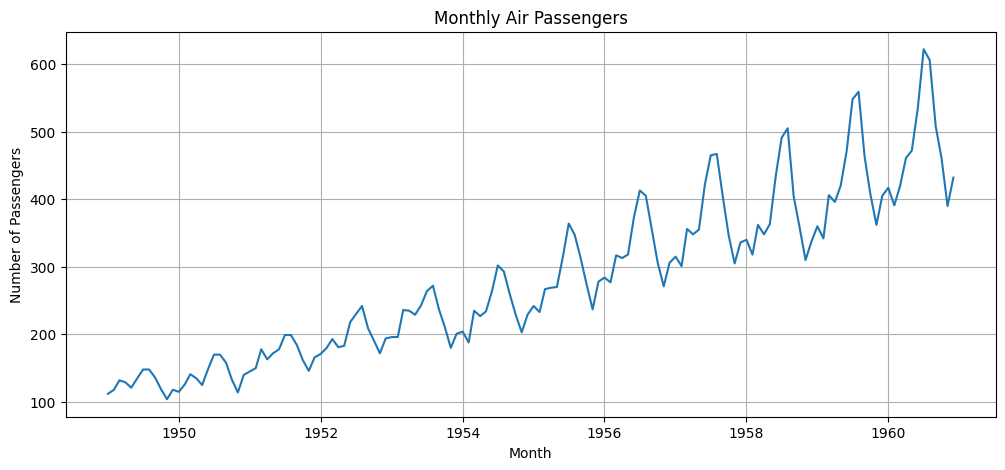

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(df["Month"], df["Passengers"])

plt.title("Monthly Air Passengers")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")

plt.grid(True)
plt.show()

#### Select the forecasting data

In [6]:
data = df["Passengers"].values

data = data.reshape(-1, 1)

print(data.shape)

(144, 1)


#### Normalize the data

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[0.01544402]
 [0.02702703]
 [0.05405405]
 [0.04826255]
 [0.03281853]]


#### Split training and testing data

In [8]:
train_size = int(len(scaled_data) * 0.80)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print("Training data:", len(train_data))
print("Testing data:", len(test_data))

Training data: 115
Testing data: 29


#### Create sequences for LSTM

In [9]:
def create_sequences(data, time_steps=12):
    X = []
    y = []

    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, 12)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (103, 12)
y_train shape: (103,)


#### Prepare test sequences

In [10]:
test_input = np.concatenate(
    (train_data[-12:], test_data),
    axis=0
)

X_test, y_test = create_sequences(test_input, 12)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (29, 12)
y_test shape: (29,)


#### Reshape the data for LSTM

In [11]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (103, 12, 1)
X_test: (29, 12, 1)


#### Build the LSTM model

In [12]:
model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(50)
)

model.add(Dropout(0.2))

model.add(Dense(1))

d:\Third Year\DL\Assignments\Exp_4\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#### Compile the model

In [13]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

#### Display the model

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the LSTM 

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0458 - val_loss: 0.0348
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0140 - val_loss: 0.0262
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0101 - val_loss: 0.0136
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0112 - val_loss: 0.0219
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0101 - val_loss: 0.0119
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0066 - val_loss: 0.0147
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0068 - val_loss: 0.0136
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0058 - val_loss: 0.0138
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0068 - val_loss: 0.0135
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0059 - val_loss: 0.0171
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0060 - val_loss: 0.0163
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0055 - val_loss: 0.0161
E

#### Plot training loss

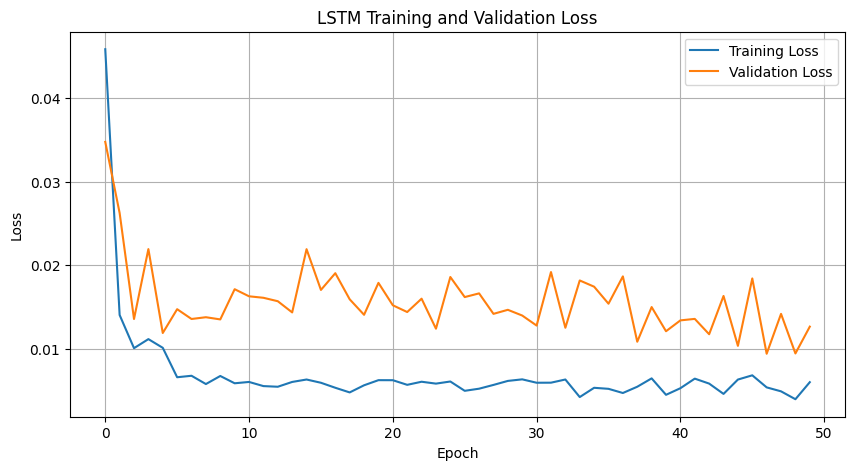

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

#### Make predictions

In [17]:
predictions = model.predict(X_test)

print(predictions.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
(29, 1)


#### Convert predictions back to original values

In [18]:
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("Predicted values:")
print(predictions[:5])

print("\nActual values:")
print(actual[:5])

Predicted values:
[[408.13385]
 [402.3829 ]
 [400.48615]
 [403.31464]
 [409.17447]]

Actual values:
[[505.]
 [404.]
 [359.]
 [310.]
 [337.]]


#### Calculate RMSE

In [19]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

print("RMSE:", rmse)

RMSE: 67.3317049898279


#### Plot Actual vs Predicted

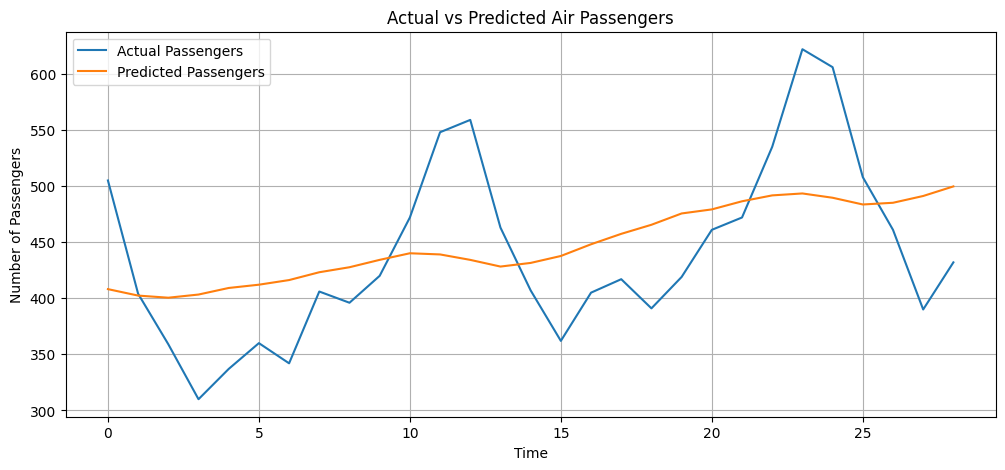

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(actual, label="Actual Passengers")
plt.plot(predictions, label="Predicted Passengers")

plt.title("Actual vs Predicted Air Passengers")
plt.xlabel("Time")
plt.ylabel("Number of Passengers")

plt.legend()
plt.grid(True)
plt.show()

#### Create a results table

In [21]:
results = pd.DataFrame({
    "Actual": actual.flatten(),
    "Predicted": predictions.flatten()
})

results.head(10)

,Actual,Predicted
0,505.0,408.133850
1,404.0,402.382904
2,359.0,400.486145
3,310.0,403.314636
4,337.0,409.174469
5,360.0,412.092133
6,342.0,416.219696
7,406.0,423.195251
8,396.0,427.654907
9,420.0,434.236603
